### The Dataset
Kaggle's Top 50 Spotify Tracks 2020 is used for the analysis.  
https://www.kaggle.com/datasets/atillacolak/top-50-spotify-tracks-2020

### Data Description  
Spotify provides a definition for its audio features.  
https://developer.spotify.com/documentation/web-api/reference/get-audio-features  

**_acousticness_**  number [float]  
A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.  
**_danceability_**  number [float]  
Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable.  
**_duration_ms_**  integer
The duration of the track in milliseconds.  
**_energy_**  number [float]  
Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy.  
**_id_**  string  
The Spotify ID for the track.  
**_instrumentalness_**  number [float]  
Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0.  
**_key_**  integer  
The (musical) key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1.  
**_liveness_**  number [float]  
Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live.  
**_loudness_**  number [float]  
The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typically range between -60 and 0 db.  
**_speechiness_**  number [float]  
Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks.  
**_tempo_**  number [float]  
The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration.  
**_valence_**  number [float]  
A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry).  


### The Context  
I am a data analyst working for Spotify. Our team is responsible for content analysis, and the goal of the analysis at hand is to quantify what makes a hit song. 

### The Insights  
Based on the dataset my findings are as follows.  

**_What have we found out about tastes and preferences of music streamers?_**  
1) There are 40 artists in the Top 50. Seven of them gave one third of the top 50 tracks, they are Dua Lipa, Billie Eilish, Travis Scott, Harry Styles, Lewis Capaldi, Justin Bieber, and Post Malone.  
Three of them - Dua Lipa, Billie Eilish, and Travis Scott - had three tracks each.  
Some of them are present with several albums (Billie Eilish, Travis Scott, and Lewis Capaldi - although the latter is just the extended version of the same album).  
2) There are four albums that managed to get several songs on the chart, three represent the Pop genre.  

3) The majority of songs (32/50) possess a high danceability score. People like music to which they can dance.  
4) Loud songs are quite popular: 19/50 are louder than -5dB.  
5) The avg length of the songs is 3 min 20 sec.  

6) The most popular genres are pop (14 tracks) and Hip-Hop/Rap (13).  

**_What are valid directions for future analysis?_**  
1) I recommend looking at *trends*. The current analysis represents a snapshot in time.  
2) Investigate other forms of *music consumption*, namely *live concerts and touring* which actually brings in more revenue than paid audio streaming as well as *vinyl record sales*. The latter is a niche market but represents significant revenue in nominal terms.  
3) In addition checking the correlation between music streaming volumes and youtube video starts would be valuable. My hypothesis is that they move together. But is there also a causation?   

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

### Load The Data

In [4]:
df = pd.read_csv('spotifytoptracks.csv', index_col=0)  

print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded dataset: 50 rows, 16 columns


In [5]:
df.sample(6)

,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre
30,Justin Bieber,Changes,Yummy,16wAOAZ2OkqoIDN7TpChjR,0.506,0.676,9,-6.652,0.3450,0.0958,0.000000,0.1180,0.497,145.842,208520,Pop
15,Drake,Dark Lane Demo Tapes,Toosie Slide,466cKvZn1j45IpxDdYZqdA,0.490,0.830,1,-8.820,0.2890,0.2090,0.000003,0.1130,0.845,81.604,247059,Hip-Hop/Rap
37,Post Malone,Hollywood's Bleeding,Sunflower - Spider-Man: Into the Spider-Verse,0RiRZpuVRbi7oqRdSMwhQY,0.522,0.755,2,-4.368,0.5330,0.0575,0.000000,0.0685,0.925,89.960,157560,Dreampop/Hip-Hop/R&B
16,Lewis Capaldi,Divinely Uninspired To A Hellish Extent (Exten...,Before You Go,2gMXnyrvIjhVBUZwvLZDMP,0.575,0.459,3,-4.858,0.6040,0.0573,0.000000,0.0885,0.183,111.881,215107,Alternative/Indie
4,Dua Lipa,Future Nostalgia,Don't Start Now,3PfIrDoz19wz7qK7tYeu62,0.793,0.793,11,-4.521,0.0123,0.0830,0.000000,0.0951,0.679,123.950,183290,Nu-disco
27,Cardi B,WAP (feat. Megan Thee Stallion),WAP (feat. Megan Thee Stallion),4Oun2ylbjFKMPTiaSbbCih,0.454,0.935,1,-7.509,0.0194,0.3750,0.000000,0.0824,0.357,133.073,187541,Hip-Hop/Trap


### Data Cleaning

#### Missing values

*Are there missing values in the dataset?*

In [6]:
df.isnull().sum()

artist              0
album               0
track_name          0
track_id            0
energy              0
danceability        0
key                 0
loudness            0
acousticness        0
speechiness         0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
genre               0
dtype: int64

#### Duplicates

*Are there duplicates in the samples and features?*

In [7]:
duplicate_rows_count = df.duplicated(subset=['artist', 'track_name']).sum()
print(f"Total duplicate rows: {duplicate_rows_count}")

duplicate_cols_count = df.T.duplicated().sum()
print(f"Total duplicate columns: {duplicate_cols_count}")

Total duplicate rows: 0
Total duplicate columns: 0


In [8]:
#display(df.columns.tolist())
df.dtypes

artist               object
album                object
track_name           object
track_id             object
energy              float64
danceability        float64
key                   int64
loudness            float64
acousticness        float64
speechiness         float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
genre                object
dtype: object

In [9]:
df['key'] = df['key'].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   artist            50 non-null     object  
 1   album             50 non-null     object  
 2   track_name        50 non-null     object  
 3   track_id          50 non-null     object  
 4   energy            50 non-null     float64 
 5   danceability      50 non-null     float64 
 6   key               50 non-null     category
 7   loudness          50 non-null     float64 
 8   acousticness      50 non-null     float64 
 9   speechiness       50 non-null     float64 
 10  instrumentalness  50 non-null     float64 
 11  liveness          50 non-null     float64 
 12  valence           50 non-null     float64 
 13  tempo             50 non-null     float64 
 14  duration_ms       50 non-null     int64   
 15  genre             50 non-null     object  
dtypes: category(1), float64(9), int64

In [11]:
df.describe()

,energy,danceability,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.609300,0.716720,-6.225900,0.256206,0.124158,0.015962,0.196552,0.555710,119.690460,199955.360000
std,0.154348,0.124975,2.349744,0.265250,0.116836,0.094312,0.176610,0.216386,25.414778,33996.122488
min,0.225000,0.351000,-14.454000,0.001460,0.029000,0.000000,0.057400,0.060500,75.801000,140526.000000
25%,0.494000,0.672500,-7.552500,0.052800,0.048325,0.000000,0.093950,0.434000,99.557250,175845.500000
50%,0.597000,0.746000,-5.991500,0.188500,0.070050,0.000000,0.111000,0.560000,116.969000,197853.500000
75%,0.729750,0.794500,-4.285500,0.298750,0.155500,0.000020,0.271250,0.726250,132.317000,215064.000000
max,0.855000,0.935000,-3.280000,0.934000,0.487000,0.657000,0.792000,0.925000,180.067000,312820.000000


In [12]:
# for categorical features
df.describe(exclude= np.number)

,artist,album,track_name,track_id,key,genre
count,50,50,50,50,50,50
unique,40,45,50,50,12,16
top,Dua Lipa,Future Nostalgia,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0,Pop
freq,3,3,1,1,6,14


In [39]:
# for categorical features using pandas
df.describe(include=['object', 'category'])

,artist,album,track_name,track_id,key,genre,duration_time
count,50,50,50,50,50,50,50
unique,40,45,50,50,12,16,41
top,Dua Lipa,Future Nostalgia,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0,Pop,03:20
freq,3,3,1,1,6,14,3


#### Outliers

*Treating outliers*

In [ ]:
# Note: A threshold of 3 * IOR was applied to isolate extreme outliers only, as a standard threshold of 1.5 * IQR was overly sensitive
# due to the naturally skewed and specialised nature of a Top 50 chart dataset.

num_df = df.select_dtypes(include=['int64', 'float64'])

print("Outlier Count Per Column:")
print("-" * 30)

# loop through each column and calculate IQR boundaries
for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    # count values that fall outside the boundaries
    outliers_count = ((num_df[col] < lower_bound) | (num_df[col] > upper_bound)).sum()
    print(f"{col}: {outliers_count} outliers")


Outlier Count Per Column:
------------------------------
energy: 0 outliers
danceability: 0 outliers
loudness: 0 outliers
acousticness: 0 outliers
speechiness: 1 outliers
instrumentalness: 11 outliers
liveness: 0 outliers
valence: 0 outliers
tempo: 0 outliers
duration_ms: 0 outliers


### Exploratory Data Analysis

In [40]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"The following are the categorical features in the dataset: ")
display(categorical_features)

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"The numeric features are: ")
numeric_features


The following are the categorical features in the dataset: 


['artist', 'album', 'track_name', 'track_id', 'key', 'genre', 'duration_time']

The numeric features are: 


['energy',
 'danceability',
 'loudness',
 'acousticness',
 'speechiness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms']

#### Popular Artists

In [18]:
counts = df['artist'].value_counts()

filtered_and_sorted = counts[counts > 1]

# Reset the index to start at 0
filtered_and_sorted = filtered_and_sorted.reset_index()

filtered_and_sorted.index = filtered_and_sorted.index + 1

filtered_and_sorted.columns = ['artist', 'num_tracks']

filtered_and_sorted


,artist,num_tracks
1,Dua Lipa,3
2,Billie Eilish,3
3,Travis Scott,3
4,Harry Styles,2
5,Lewis Capaldi,2
6,Justin Bieber,2
7,Post Malone,2


In [19]:
target_artists = ['Dua Lipa', 'Billie Eilish', 'Travis Scott', 'Harry Styles', 'Lewis Capaldi', 'Justin Bieber', 'Post Malone']

# Use .loc[row_selection, column_selection]
filtered_df = df.loc[df['artist'].isin(target_artists), ['artist', 'album', 'track_name']]
filtered_df

,artist,album,track_name
4,Dua Lipa,Future Nostalgia,Don't Start Now
6,Harry Styles,Fine Line,Watermelon Sugar
9,Lewis Capaldi,Divinely Uninspired To A Hellish Extent,Someone You Loved
12,Post Malone,Hollywood's Bleeding,Circles
14,Justin Bieber,Changes,Intentions (feat. Quavo)
16,Lewis Capaldi,Divinely Uninspired To A Hellish Extent (Exten...,Before You Go
21,Harry Styles,Fine Line,Adore You
24,Billie Eilish,everything i wanted,everything i wanted
26,Billie Eilish,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",bad guy
30,Justin Bieber,Changes,Yummy


*How many artists have their songs in the top 50 in total?*  
40

In [20]:
df['artist'].nunique()

40

#### Popular Albums

*Albums that have more than one track in the Top 50*  

In [42]:
# aggregate: count the tracks and grab the first genre found for that album
counts = df.groupby(['artist', 'album']).agg(
    track_count=('track_name', 'size'),
    track_names=('track_name', ', '.join),
    genre=('genre', 'first')
).reset_index()

filtered_and_sorted = counts[counts['track_count'] > 1].sort_values(by='track_count', ascending=False)
filtered_and_sorted


,artist,album,track_count,track_names,genre
14,Dua Lipa,Future Nostalgia,3,"Don't Start Now, Break My Heart, Physical",Nu-disco
17,Harry Styles,Fine Line,2,"Watermelon Sugar, Adore You",Pop
21,Justin Bieber,Changes,2,"Intentions (feat. Quavo), Yummy",Pop
29,Post Malone,Hollywood's Bleeding,2,"Circles, Sunflower - Spider-Man: Into the Spid...",Pop/Soft Rock


*How many albums in total have their songs in the top 50?*  
45


In [22]:
df['album'].nunique()

45

#### Instrumentalness

In [55]:
instrumentalness_series = df['instrumentalness']
sorted_instrumentalness = instrumentalness_series.sort_values(ascending=False)
display(sorted_instrumentalness)

df.loc[24, ['instrumentalness', 'artist', 'track_name']]

24    0.657000
26    0.130000
3     0.004320
12    0.002440
34    0.001880
41    0.001090
48    0.000658
33    0.000209
1     0.000161
10    0.000134
0     0.000095
39    0.000064
38    0.000025
21    0.000007
36    0.000006
17    0.000004
15    0.000003
31    0.000001
16    0.000000
14    0.000000
11    0.000000
13    0.000000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
5     0.000000
4     0.000000
2     0.000000
23    0.000000
25    0.000000
20    0.000000
19    0.000000
18    0.000000
32    0.000000
30    0.000000
28    0.000000
29    0.000000
27    0.000000
22    0.000000
37    0.000000
35    0.000000
40    0.000000
42    0.000000
44    0.000000
43    0.000000
45    0.000000
46    0.000000
47    0.000000
49    0.000000
Name: instrumentalness, dtype: float64

instrumentalness                  0.657
artist                    Billie Eilish
track_name          everything i wanted
Name: 24, dtype: object

#### Speechiness

In [ ]:
speechiness_series = df['speechiness']
sorted_speechiness = speechiness_series.sort_values(ascending=False)
display(sorted_speechiness)

print(df.loc[19, ['speechiness', 'artist', 'track_name']])

#### Danceability

*Which tracks have a danceability score above 0.7?*  

In [23]:
dancey_df = df.loc[df['danceability'] > 0.7, ['artist', 'track_name', 'danceability']].sort_values(by='danceability', ascending=False)
num_dancey = len(dancey_df)
print(f"There are {num_dancey} dancey songs in the Top 50.")
dancey_df


There are 32 dancey songs in the Top 50.


,artist,track_name,danceability
27,Cardi B,WAP (feat. Megan Thee Stallion),0.935
2,Roddy Ricch,The Box,0.896
39,Regard,Ride It,0.880
28,Surfaces,Sunday Best,0.878
33,BENEE,Supalonely (feat. Gus Dapperton),0.862
40,Travis Scott,goosebumps,0.841
49,Travis Scott,SICKO MODE,0.834
15,Drake,Toosie Slide,0.830
1,Tones And I,Dance Monkey,0.825
29,Eminem,Godzilla (feat. Juice WRLD),0.808


*Which tracks have a danceability score below 0.4?*  

In [24]:
not_dancey_df = df.loc[df['danceability'] < 0.4, ['artist', 'track_name', 'danceability']]
num_not_dancey = len(not_dancey_df)
print(f"There is {num_not_dancey} undancey song in the Top 50.")
not_dancey_df

There is 1 undancey song in the Top 50.


,artist,track_name,danceability
44,Billie Eilish,lovely (with Khalid),0.351


#### Loudness

*Which tracks have their loudness above -5?*  

A note on how to interpret the 'loudness' column.  
In digital audio, 0 dB is the absolute maximum ceiling of volume a computer can produce without distorting or clipping the sound.  
Because 0 is the maximum, any volume below the maximum must be a negative number.   
-60 dB is extremely quiet (almost total silence).  
-12 dB to -15 dB is moderately quiet (typical for older music, acoustic tracks, or dynamic classical music).  
-4 dB to -7 dB is very loud (the standard range for modern hit pop, rap, and electronic music in the Top 50). 

In [43]:
loudness_df = df.loc[df['loudness'] > -5, ['artist', 'track_name', 'loudness']].sort_values(by='loudness', ascending=False)
num_loudness = len(loudness_df)
print(f"There are {num_loudness} loud songs in the Top 50.")
loudness_df

There are 19 loud songs in the Top 50.


,artist,track_name,loudness
10,KAROL G,Tusa,-3.280
40,Travis Scott,goosebumps,-3.370
31,Dua Lipa,Break My Heart,-3.434
38,Maluma,Hawái,-3.454
12,Post Malone,Circles,-3.497
23,24kGoldn,Mood (feat. iann dior),-3.558
21,Harry Styles,Adore You,-3.675
49,Travis Scott,SICKO MODE,-3.714
48,Dua Lipa,Physical,-3.756
35,Lady Gaga,Rain On Me (with Ariana Grande),-3.764


*Which tracks have their loudness below -8?*

In [26]:
quiet_df = df.loc[df['loudness'] < -8, ['artist', 'track_name', 'loudness']].sort_values(by='loudness')
num_quiet = len(quiet_df)
print(f"There are {num_quiet} soft quiet songs in the Top 50.") 
quiet_df

There are 9 soft quiet songs in the Top 50.


,artist,track_name,loudness
24,Billie Eilish,everything i wanted,-14.454
26,Billie Eilish,bad guy,-10.965
44,Billie Eilish,lovely (with Khalid),-10.109
47,JP Saxe,If the World Was Ending - feat. Julia Michaels,-10.086
15,Drake,Toosie Slide,-8.820
7,Powfu,death bed (coffee for your head),-8.765
36,Travis Scott,HIGHEST IN THE ROOM,-8.764
8,Trevor Daniel,Falling,-8.756
20,Jawsh 685,Savage Love (Laxed - Siren Beat),-8.520


#### Length

*Which tracks are the longest and the shortest?*  

In [44]:
# format ms as minutes:seconds (MM:SS) for ease of comprehension
df['duration_time'] = pd.to_datetime(df['duration_ms'], unit='ms').dt.strftime('%M:%S')

# this will list all tracks in case of a tie
longest_song = df.loc[df['duration_ms'] == df['duration_ms'].max(), ['artist', 'album', 'track_name', 'duration_time']]
shortest_song = df.loc[df['duration_ms'] == df['duration_ms'].min(), ['artist', 'album', 'track_name', 'duration_time']]

print(f"The longest song is: ")
display(longest_song)
print(f"The shortest song is: ") 
shortest_song

The longest song is: 


,artist,album,track_name,duration_time
49,Travis Scott,ASTROWORLD,SICKO MODE,05:12


The shortest song is: 


,artist,album,track_name,duration_time
23,24kGoldn,Mood (feat. iann dior),Mood (feat. iann dior),02:20


#### Popular Genres

*Which genre is the most popular?*  
*Which genre has just one song in the top 50?*

In [45]:
df['genre'].value_counts()

genre
Pop                                   14
Hip-Hop/Rap                           13
Dance/Electronic                       5
Alternative/Indie                      4
R&B/Soul                               2
 Electro-pop                           2
R&B/Hip-Hop alternative                1
Nu-disco                               1
Pop/Soft Rock                          1
Pop rap                                1
Hip-Hop/Trap                           1
Dance-pop/Disco                        1
Disco-pop                              1
Dreampop/Hip-Hop/R&B                   1
Alternative/reggaeton/experimental     1
Chamber pop                            1
Name: count, dtype: int64

In [30]:
genre_counts = df['genre'].value_counts()
only_one_song = genre_counts[genre_counts == 1].index.tolist()
print(f"The following genres have only one song in the Top 50: ")
only_one_song

The following genres have only one song in the Top 50: 


['R&B/Hip-Hop alternative',
 'Nu-disco',
 'Pop/Soft Rock',
 'Pop rap',
 'Hip-Hop/Trap',
 'Dance-pop/Disco',
 'Disco-pop',
 'Dreampop/Hip-Hop/R&B',
 'Alternative/reggaeton/experimental',
 'Chamber pop']

*How many genres in total are represented in the top 50?*

In [31]:
df['genre'].nunique()

16

#### Correlation Among Features

*Which features are strongly positively or negatively correlated?*  
*Which features are not correlated?*

In [46]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
corr_matrix

,energy,danceability,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
energy,1.000000,0.152552,0.791640,-0.682479,0.074267,-0.385515,0.069487,0.393453,0.075191,0.081971
danceability,0.152552,1.000000,0.167147,-0.359135,0.226148,-0.017706,-0.006648,0.479953,0.168956,-0.033763
loudness,0.791640,0.167147,1.000000,-0.498695,-0.021693,-0.553735,-0.069939,0.406772,0.102097,0.064130
acousticness,-0.682479,-0.359135,-0.498695,1.000000,-0.135392,0.352184,-0.128384,-0.243192,-0.241119,-0.010988
speechiness,0.074267,0.226148,-0.021693,-0.135392,1.000000,0.028948,-0.142957,0.053867,0.215504,0.366976
instrumentalness,-0.385515,-0.017706,-0.553735,0.352184,0.028948,1.000000,-0.087034,-0.203283,0.018853,0.184709
liveness,0.069487,-0.006648,-0.069939,-0.128384,-0.142957,-0.087034,1.000000,-0.033366,0.025457,-0.090188
valence,0.393453,0.479953,0.406772,-0.243192,0.053867,-0.203283,-0.033366,1.000000,0.045089,-0.039794
tempo,0.075191,0.168956,0.102097,-0.241119,0.215504,0.018853,0.025457,0.045089,1.000000,0.130328
duration_ms,0.081971,-0.033763,0.064130,-0.010988,0.366976,0.184709,-0.090188,-0.039794,0.130328,1.000000


In [51]:
lower_triangle_df = corr_matrix.where(np.tril(np.ones(corr_matrix.shape)).astype(bool))

# 2. Define the highlighting function (expects numeric inputs)
def highlight_correlation(val):
    if pd.isna(val) or val == 1.0:
        return ''  # No styling for empty cells or perfect 1.0 correlations
    elif val > 0.4:
        return 'background-color: #d4edda; color: #155724; font-weight: bold;'  # Soft Green
    elif val < -0.4:
        return 'background-color: #f8d7da; color: #721c24; font-weight: bold;'  # Soft Red
    else:
        return ''

styled_matrix = (lower_triangle_df.style
                 .applymap(highlight_correlation)
                 .format(formatter="{:.4f}", na_rep=""))

# lower_triangle_df.map(lambda x: f"{x:.4f}" if pd.notnull(x) else "")

styled_matrix

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23288\2967331695.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_correlation)


,energy,danceability,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
energy,1.0000,,,,,,,,,
danceability,0.1526,1.0000,,,,,,,,
loudness,0.7916,0.1671,1.0000,,,,,,,
acousticness,-0.6825,-0.3591,-0.4987,1.0000,,,,,,
speechiness,0.0743,0.2261,-0.0217,-0.1354,1.0000,,,,,
instrumentalness,-0.3855,-0.0177,-0.5537,0.3522,0.0289,1.0000,,,,
liveness,0.0695,-0.0066,-0.0699,-0.1284,-0.1430,-0.0870,1.0000,,,
valence,0.3935,0.4800,0.4068,-0.2432,0.0539,-0.2033,-0.0334,1.0000,,
tempo,0.0752,0.1690,0.1021,-0.2411,0.2155,0.0189,0.0255,0.0451,1.0000,
duration_ms,0.0820,-0.0338,0.0641,-0.0110,0.3670,0.1847,-0.0902,-0.0398,0.1303,1.0000


In [52]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# unstack matrix into pairs
pairs = corr_matrix.unstack()

strong_positive = pairs[(pairs > 0.4) & (pairs < 1.0)].drop_duplicates()

print("Strongly Positively Correlated Features: ")
display(strong_positive)

strong_negative = pairs[(pairs < -0.4)].drop_duplicates()

print("Strongly Negatively Correlated Features: ") 
display(strong_negative)

not_correlated = pairs[pairs.abs() < 0.1].drop_duplicates()

print("Uncorrelated Features (Independent Pairs): ")
not_correlated

Strongly Positively Correlated Features: 


energy        loudness    0.791640
danceability  valence     0.479953
loudness      valence     0.406772
dtype: float64

Strongly Negatively Correlated Features: 


energy    acousticness       -0.682479
loudness  acousticness       -0.498695
          instrumentalness   -0.553735
dtype: float64

Uncorrelated Features (Independent Pairs): 


energy            speechiness         0.074267
                  liveness            0.069487
                  tempo               0.075191
                  duration_ms         0.081971
danceability      instrumentalness   -0.017706
                  liveness           -0.006648
                  duration_ms        -0.033763
loudness          speechiness        -0.021693
                  liveness           -0.069939
                  duration_ms         0.064130
acousticness      duration_ms        -0.010988
speechiness       instrumentalness    0.028948
                  valence             0.053867
instrumentalness  liveness           -0.087034
                  tempo               0.018853
liveness          valence            -0.033366
                  tempo               0.025457
                  duration_ms        -0.090188
valence           tempo               0.045089
                  duration_ms        -0.039794
dtype: float64

#### Genre Comparisons

*How does the danceability score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?*   
A box plot is used to give a more powerful visual representation of the genre values for danceability.  

<Axes: xlabel='genre', ylabel='danceability'>

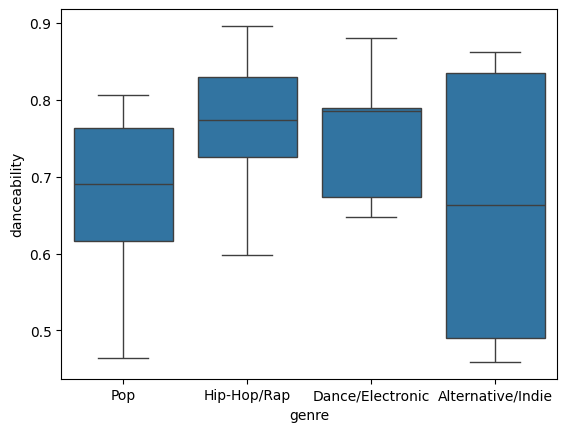

In [53]:
target_genres = ['Pop', 'Hip-Hop/Rap', 'Dance/Electronic', 'Alternative/Indie']

filtered_df = df[df['genre'].isin(target_genres)]

sns.boxplot(data=filtered_df, x='genre', y='danceability', order=target_genres)

In [54]:
target_genres = ['Pop', 'Hip-Hop/Rap', 'Dance/Electronic', 'Alternative/Indie']
filtered_df = df[df['genre'].isin(target_genres)]

genre_summary = filtered_df.groupby('genre')['danceability'].agg([
    'count',                                # number of songs
    'mean',
    'min',                                  # bottom whisker limit (approx)
    ('q25', lambda x: x.quantile(0.25)),    # bottom of the box
    'median',                               # line inside the box
    ('q75', lambda x: x.quantile(0.75)),    # top of the box
    'max',                                  # top whisker limit (approx)
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25)) # box height
])

genre_summary


,count,mean,min,q25,median,q75,max,iqr
genre,,,,,,,,
Alternative/Indie,4,0.661750,0.459,0.49050,0.663,0.83425,0.862,0.34375
Dance/Electronic,5,0.755000,0.647,0.67400,0.785,0.78900,0.880,0.11500
Hip-Hop/Rap,13,0.765538,0.598,0.72600,0.774,0.83000,0.896,0.10400
Pop,14,0.677571,0.464,0.61575,0.690,0.76275,0.806,0.14700


*How does the loudness score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?*  
Note: values closer to zero are louder

<Axes: xlabel='genre', ylabel='loudness'>

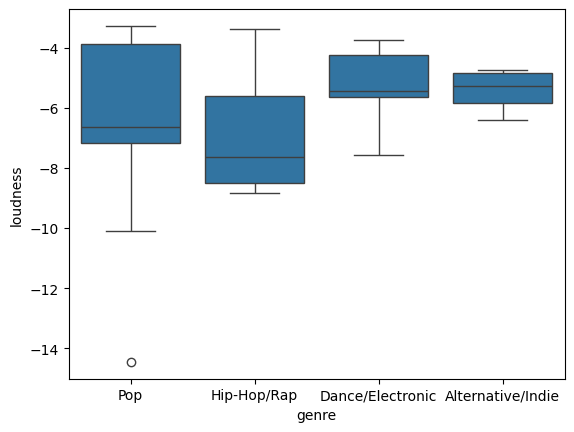

In [37]:
target_genres = ['Pop', 'Hip-Hop/Rap', 'Dance/Electronic', 'Alternative/Indie']

filtered_df = df[df['genre'].isin(target_genres)]

sns.boxplot(data=filtered_df, x='genre', y='loudness', order=target_genres)

*How does the acoustics score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?*


<Axes: xlabel='genre', ylabel='acousticness'>

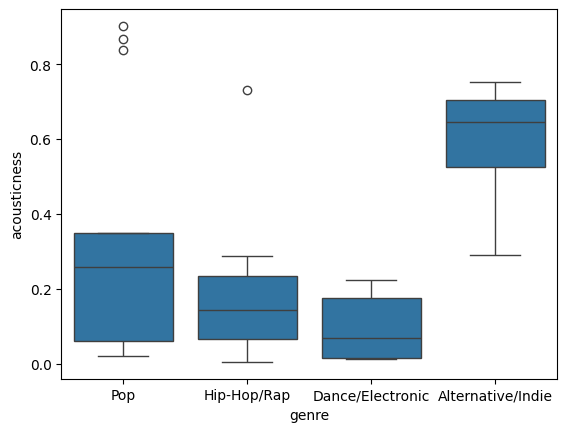

In [38]:
target_genres = ['Pop', 'Hip-Hop/Rap', 'Dance/Electronic', 'Alternative/Indie']

filtered_df = df[df['genre'].isin(target_genres)]

sns.boxplot(data=filtered_df, x='genre', y='acousticness', order=target_genres)